# Exploratory Data Analysis — Network Anomaly Detection

This notebook loads the synthetic CICIDS2017-style dataset and performs initial exploration:
shape, data types, missing values, class distribution, correlations, and per-feature distributions.
We then drop redundant features (zero-variance and those with pairwise correlation > 0.95) to
prepare a cleaner feature set for downstream modelling.

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook', palette='Set2')
%matplotlib inline

FIG_DIR = os.path.join('..', 'outputs', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

def save_plot(fname: str) -> str:
    path = os.path.join(FIG_DIR, f'eda_{fname}.png')
    plt.savefig(path, dpi=150, bbox_inches='tight', facecolor='white')
    return path

## 1. Load the data

In [2]:
DATA_PATH = os.path.join('..', 'data', 'cicids_sample.csv')
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

Shape: 50,000 rows × 85 columns


## 2. Data types and missing values

We inspect column types to separate numeric predictors from identifiers, and check for nulls.

In [3]:
dtype_counts = df.dtypes.value_counts()
display(dtype_counts)
print()

nulls = df.isnull().sum()
null_cols = nulls[nulls > 0]
if len(null_cols) == 0:
    print('No missing values in any column.')
else:
    print(f'{len(null_cols)} columns have missing values:')
    display(null_cols)

float64    44
int64      35
object      6
Name: count, dtype: int64


No missing values in any column.


## 3. Class distribution

The `Label` column holds the ground-truth class. A severe imbalance is expected — benign traffic
should dominate.

In [4]:
label_col = 'Label'
class_counts = df[label_col].value_counts()
class_pct = (df[label_col].value_counts(normalize=True) * 100).round(2)
summary = pd.DataFrame({'Count': class_counts, 'Percent': class_pct})
display(summary)

,Count,Percent
Label,,
BENIGN,32500,65.00
DDoS,5289,10.58
PortScan,5181,10.36
Bot,2698,5.40
Web Attack,1716,3.43
Infiltration,882,1.76
Heartbleed,878,1.76
Brute Force,856,1.71


## 4. Class imbalance bar chart

A horizontal bar plot makes the imbalance immediately visible.

Saved ../outputs/figures/eda_class_imbalance.png


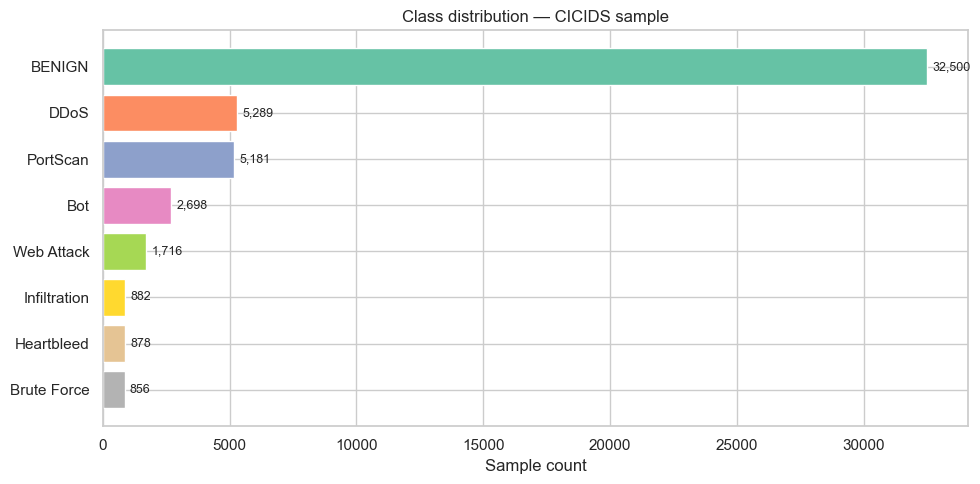

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
order = class_counts.index.tolist()
bars = ax.barh(order, class_counts.values, color=sns.color_palette('Set2', len(order)))
ax.set_xlabel('Sample count')
ax.set_title('Class distribution — CICIDS sample')
ax.invert_yaxis()
for bar, val in zip(bars, class_counts.values):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
saved = save_plot('class_imbalance')
print(f'Saved {saved}')
plt.show()

## 5. Correlation heatmap (top 30 features by variance)

We isolate numeric columns, drop the label, and select the 30 features with the highest
variance for a compact correlation heatmap. This helps spot highly correlated groups.

Saved ../outputs/figures/eda_correlation_heatmap.png


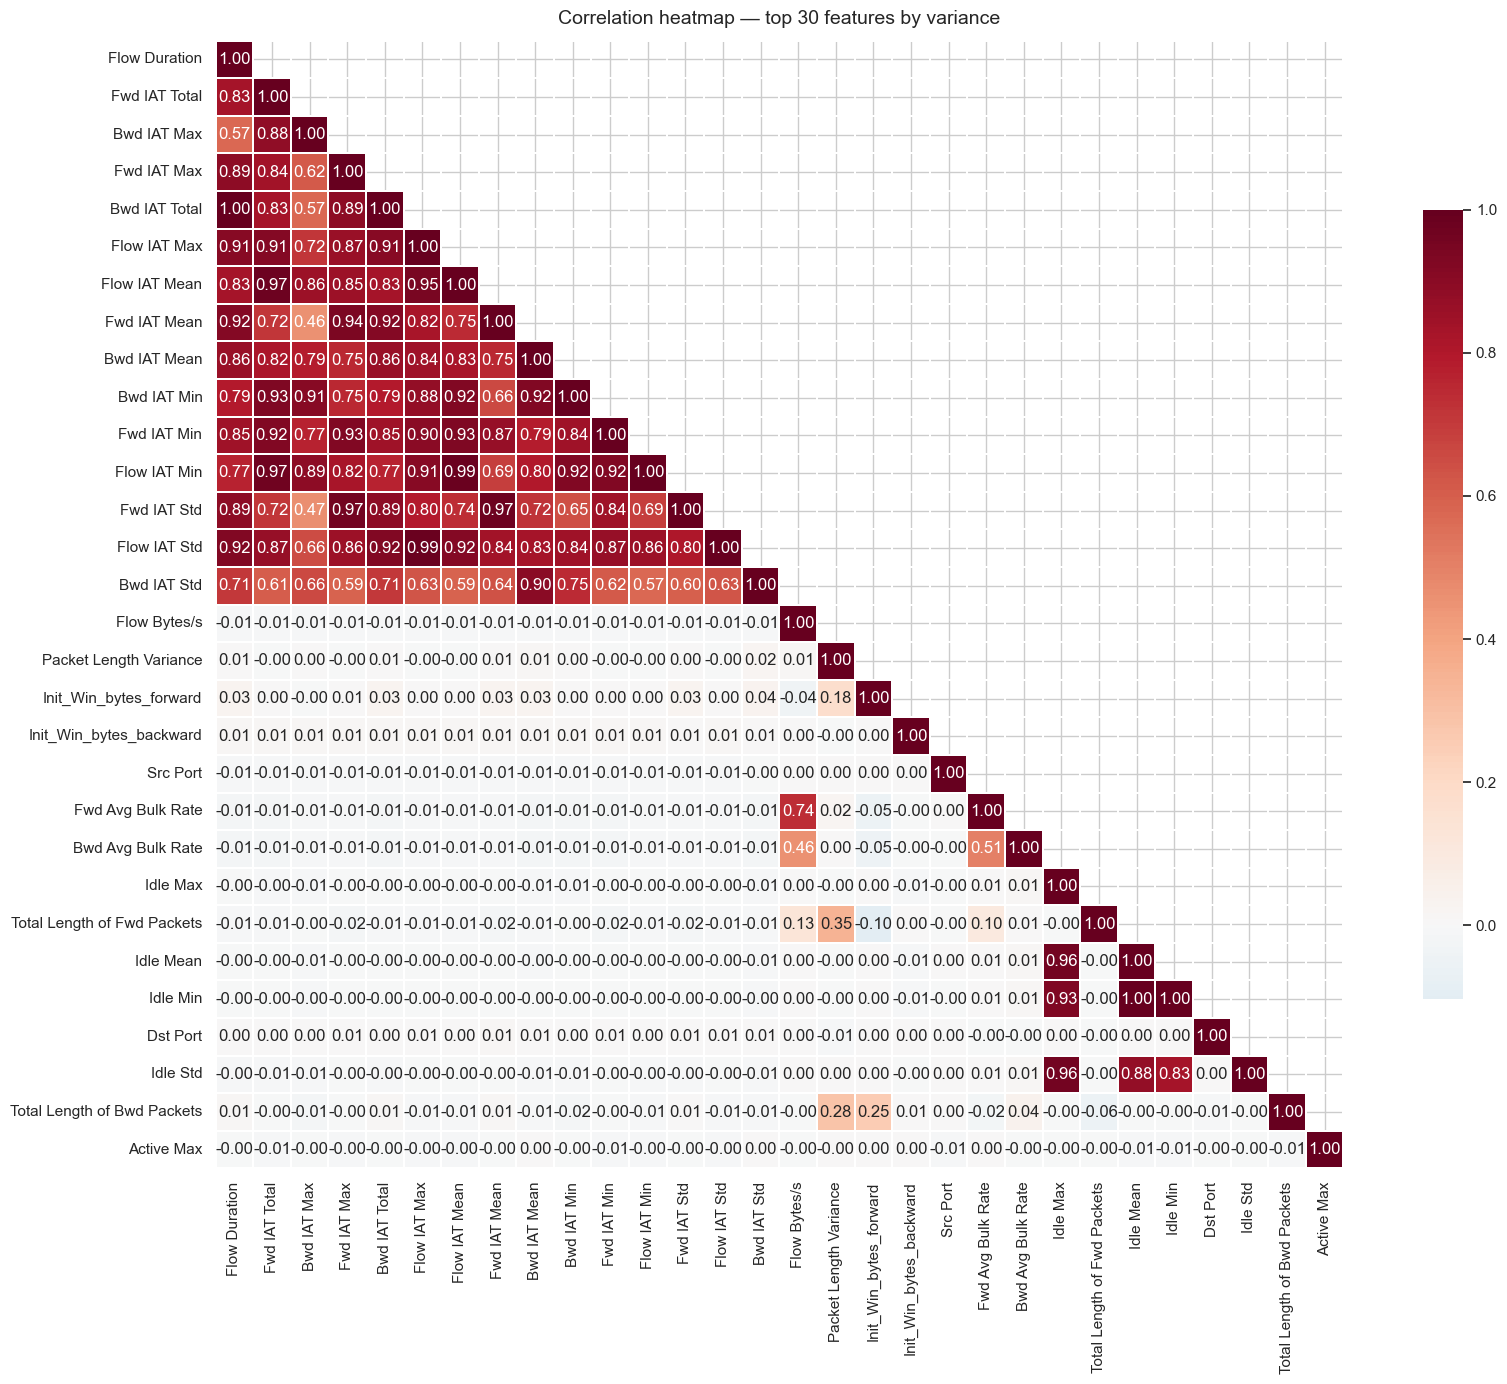

In [6]:
# Select numeric features and exclude identifier / label columns
exclude = {'Flow ID', 'Src IP', 'Dst IP', 'Timestamp', 'Label'}
numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in exclude]

# Pick top 30 by variance
variances = df[numeric_cols].var().sort_values(ascending=False)
top30 = variances.head(30).index.tolist()
corr = df[top30].corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.3,
            cbar_kws={'shrink': 0.7}, ax=ax)
ax.set_title('Correlation heatmap — top 30 features by variance', fontsize=14, pad=12)
plt.tight_layout()
saved = save_plot('correlation_heatmap')
print(f'Saved {saved}')
plt.show()

## 6. Feature distribution plots

We examine the distributions of six representative features, split by label, to inspect
whether different attack classes produce visibly different value ranges.

Saved ../outputs/figures/eda_feature_distributions.png


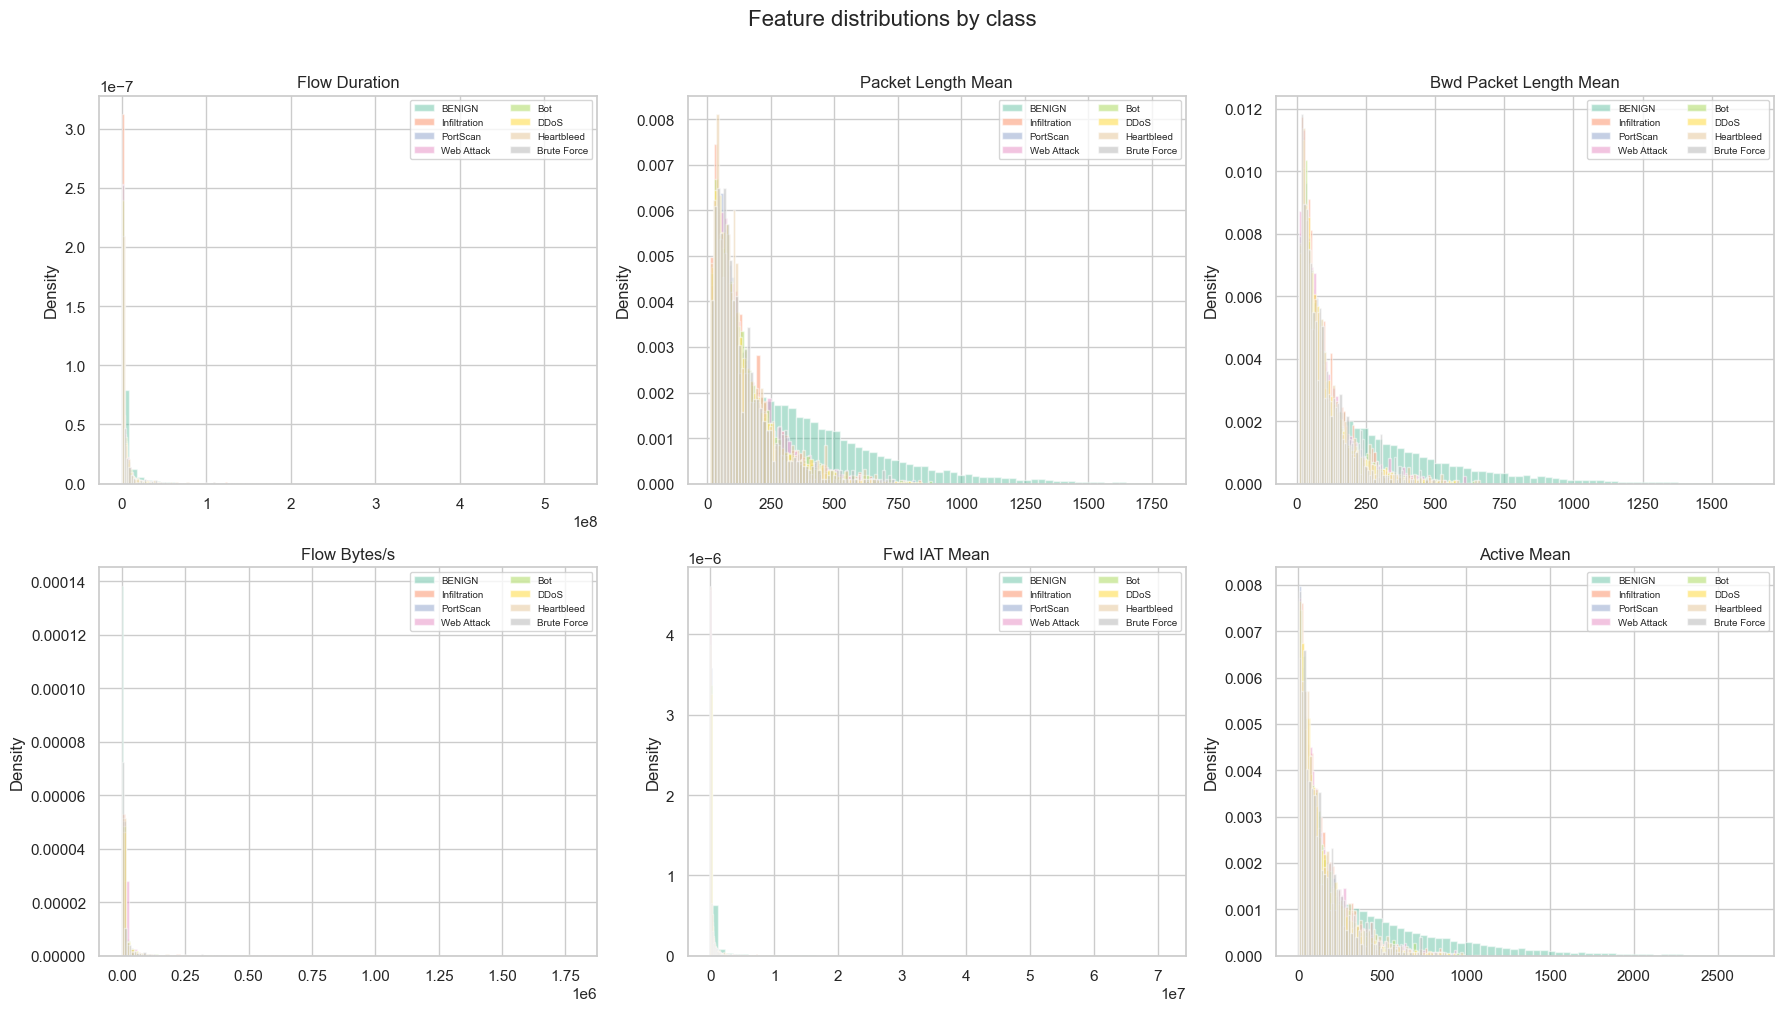

In [7]:
plot_features = {
    'Flow Duration': 'flow_duration',
    'Packet Length Mean': 'packet_length_mean',
    'Bwd Packet Length Mean': 'bwd_pkt_len_mean',
    'Flow Bytes/s': 'flow_bytes_per_sec',
    'Fwd IAT Mean': 'fwd_iat_mean',
    'Active Mean': 'active_mean',
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (feat_name, slug) in zip(axes, plot_features.items()):
    for cls in df[label_col].unique():
        vals = df.loc[df[label_col] == cls, feat_name]
        # Trim extreme outliers for readability
        lo, hi = vals.quantile(0.005), vals.quantile(0.995)
        vals_trim = vals[(vals >= lo) & (vals <= hi)]
        ax.hist(vals_trim, bins=60, alpha=0.5, label=cls, density=True)

    ax.set_title(feat_name)
    ax.set_xlabel('')
    ax.set_ylabel('Density')
    ax.legend(fontsize=7, loc='upper right', ncol=2)

plt.suptitle('Feature distributions by class', fontsize=16, y=1.01)
plt.tight_layout()
saved = save_plot('feature_distributions')
print(f'Saved {saved}')
plt.show()

## 7. Remove low-variance and highly correlated features

- **Zero-variance features**: columns whose standard deviation is zero (they provide no signal).
- **High correlation**: for each group of features with pairwise |r| > 0.95, we keep the one
  with the highest variance and drop the rest.

This reduces multicollinearity and speeds up downstream training.

In [8]:
feat_cols = [c for c in numeric_cols if c in df.columns]
X = df[feat_cols].copy()

# --- Zero variance ---
std = X.std()
zero_var = std[std == 0].index.tolist()
print(f'Zero-variance features ({len(zero_var)}): {zero_var if zero_var else "None"}')
X = X.drop(columns=zero_var, errors='ignore')

# --- High correlation ---
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape, dtype=bool), k=1))
to_drop = set()

for col in upper.columns:
    high_corr = upper[col][upper[col] > 0.95].index.tolist()
    for other in high_corr:
        # Drop the one with lower variance
        if X[col].var() >= X[other].var():
            to_drop.add(other)
        else:
            to_drop.add(col)

print(f'Dropping {len(to_drop)} highly correlated features')
if to_drop:
    print(f'Dropped: {sorted(to_drop)}')
X_clean = X.drop(columns=list(to_drop), errors='ignore')

print(f'\nFinal feature count: {X_clean.shape[1]}')

Zero-variance features (1): ['CWE Flag Count']


Dropping 13 highly correlated features
Dropped: ['Active Std', 'Bwd IAT Total', 'Bwd Packet Length Mean', 'Bwd Packet Length Min', 'Flow IAT Mean', 'Flow IAT Min', 'Flow IAT Std', 'Fwd IAT Std', 'Fwd Packet Length Min', 'Fwd Packets/s', 'Idle Mean', 'Idle Min', 'Idle Std']

Final feature count: 65


## 8. Final class split summary

The cleaned dataset still contains all rows; only columns have been removed.

In [9]:
final_df = X_clean.copy()
final_df[label_col] = df[label_col]
print(f'Final shape: {final_df.shape[0]:,} rows × {final_df.shape[1]} columns')
print()
split = final_df[label_col].value_counts()
split_pct = (split / split.sum() * 100).round(2)
final_summary = pd.DataFrame({'Count': split, 'Percent': split_pct})
display(final_summary)

Final shape: 50,000 rows × 66 columns



,Count,Percent
Label,,
BENIGN,32500,65.00
DDoS,5289,10.58
PortScan,5181,10.36
Bot,2698,5.40
Web Attack,1716,3.43
Infiltration,882,1.76
Heartbleed,878,1.76
Brute Force,856,1.71


## 9. Summary

- The raw dataset contains **84 numeric features** plus a `Label` column.
- There are **no missing values**.
- The class distribution is heavily skewed toward **BENIGN (65 %)**, as expected in real
  network traffic.
- Several highly correlated feature groups were identified and pruned; the cleaned set
  retains only one representative per group.
- All plots have been saved to `outputs/figures/eda_*.png`.